In [1]:
import asyncio
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
import sys
from pathlib import Path

# Asumiendo que notebooks/ está dentro de la raíz del proyecto
root_path = Path().resolve().parent  # sube un nivel
sys.path.append(str(root_path))

In [3]:
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent
from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader
import pandas as pd

In [ ]:
import asyncio
import numpy as np
import torch

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader

from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent

from explainers.shap_explainer import ShapExplainer

from models.sklearn_model import SklearnModel
from models.torch_model import TorchModel
from models.random_forest import RandomForest as AdvancedRF

# Visualización (todo en un solo módulo como acordamos)
from visualization.visualization import (
    plot_metrics_over_time,
    plot_explanation_similarity,
    plot_explanation_divergence,
    plot_agents_dashboard
)

from visualization.logs import log

import torch.nn as nn
from models.torch_model import TorchModel

class IrisMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)



async def run_test():
    print("\n==================== TEST MULTI-AGENT ====================")

    # ------------------- Dataset -------------------
    registry = DatasetRegistry()
    dataset_id = "iris"
    registry.register(dataset_id, SklearnLoader(load_iris))

    X, y, meta = registry.load(dataset_id)
    print(f"[Dataset] {dataset_id} cargado → X={X.shape}, y={y.shape}")

    instance = X[:1]

    # ------------------- Modelos -------------------
    rf_base = SklearnModel(
        RandomForestClassifier(n_estimators=20, random_state=0)
    )

    rf_adv = AdvancedRF(
        n_estimators=30,
        max_depth=5,
        random_state=1
    )

        # ------------------- Modelos MUY MALOS -------------------

    # RF extremadamente débil
    rf_very_bad = SklearnModel(
        RandomForestClassifier(
            n_estimators=1,
            max_depth=1,
            random_state=0
        )
    )
    def noisy_labels(y, noise_ratio=0.4, seed=0):
        """
        Introduce ruido en las etiquetas.
        
        noise_ratio : proporción de etiquetas a corromper (0–1)
        seed        : reproducibilidad
        """
        rng = np.random.default_rng(seed)

        y_noisy = y.copy()
        n_classes = len(np.unique(y))

        n_noisy = int(len(y) * noise_ratio)
        idx = rng.choice(len(y), size=n_noisy, replace=False)

        # Asignar etiquetas aleatorias distintas de la original
        for i in idx:
            possible = list(range(n_classes))
            possible.remove(y[i])
            y_noisy[i] = rng.choice(possible)

        return y_noisy
    # RF con ruido en etiquetas (simula dataset mal anotado)
    y_noisy = noisy_labels(y, noise_ratio=0.4)

    class NoisyRFModel(SklearnModel):
        def fit(self, X, y):
            super().fit(X, y_noisy)

    rf_noisy = NoisyRFModel(
        RandomForestClassifier(
            n_estimators=10,
            max_depth=3,
            random_state=1
        )
    )

    # Red neuronal casi sin entrenar
    torch_bad = TorchModel(
        nn_model=IrisMLP(input_dim=X.shape[1], hidden_dim=4),
        lr=1e-4,
        epochs=1,
        batch_size=32
    )

    # ------------------- Clasificadores -------------------
    classifiers = {
        "rf_very_bad": ClassifierAgent(
            agent_id="rf_very_bad",
            model=rf_very_bad,
            explainers=[ShapExplainer()],
            dataset_id=dataset_id,
            registry=registry
        ),
        "rf_noisy": ClassifierAgent(
            agent_id="rf_noisy",
            model=rf_noisy,
            explainers=[ShapExplainer()],
            dataset_id=dataset_id,
            registry=registry
        ),
        "nn_very_bad": ClassifierAgent(
            agent_id="nn_very_bad",
            model=torch_bad,
            explainers=[ShapExplainer()],
            dataset_id=dataset_id,
            registry=registry
        )
    }

    classifier_ids = list(classifiers.keys())

    # ------------------- Aggregator -------------------
    aggregator = AggregatorAgent(
        classifier_ids=classifier_ids,
        max_iterations=6,   # 🔴 solo 2 iteraciones para depuración
        alpha=0.4,
        beta=0.15,
        gamma=0.25
    )

    # ------------------- Queues -------------------
    queues = {cid: agent.inbox for cid, agent in classifiers.items()}
    queues["aggregator"] = aggregator.inbox

    # ------------------- Setup -------------------
    print("\n[Setup] Inicializando agentes...\n")
    await asyncio.gather(*(agent.setup() for agent in classifiers.values()))
    log("Inicializando AggregatorAgent")

    # ------------------- Tasks -------------------
    tasks = [
        asyncio.create_task(agent.run(queues))
        for agent in classifiers.values()
    ]
    tasks.append(
        asyncio.create_task(
            aggregator.run(queues, instance)
        )
    )

    await asyncio.gather(*tasks)

    print("\n==================== TEST FINALIZADO ✅ ====================\n")

    # =========================================================
    # VISUALIZACIÓN
    # =========================================================

    print("\n[Visualización] Métricas por agente\n")

    for agent in classifiers.values():
        plot_metrics_over_time(agent.metrics_history, metric_name="accuracy")
        plot_metrics_over_time(agent.metrics_history, metric_name="f1")

        plot_explanation_similarity(agent)

    print("\n[Visualización] Divergencia global de explicaciones\n")
    plot_explanation_divergence(classifiers)

    print("\n[Visualización] Dashboard global\n")
    plot_agents_dashboard(classifiers)

    rows = []

    for entry in aggregator.global_history:
        iteration = entry["iteration"]
        evaluation = entry["evaluation"]
        exp_detail = evaluation["components"]["exp_detail"]

        for idx, agent_id in enumerate(classifier_ids):
            row = {
                "agent": agent_id,
                "iteration": iteration,
                "accuracy": entry["responses"][idx]["metrics"]["accuracy"],
                "f1": entry["responses"][idx]["metrics"]["f1"],
                "precision": entry["responses"][idx]["metrics"]["precision"],
                "recall": entry["responses"][idx]["metrics"]["recall"],
                # 🔹 métricas explicativas
                "exp_quality": exp_detail["quality"][idx],
                "exp_consensus": exp_detail["consensus"][idx],
                "exp_stability": exp_detail["stability"][idx],
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    return df.sort_values(["agent", "iteration"])
    


==================== TEST MULTI-AGENT ====================
[Dataset] iris cargado → X=(150, 4), y=(150,)

[Setup] Inicializando agentes...

[rf_base] Setup iniciado
[rf_base] 16:26:54 | Setup iniciado (train + eval inicial)
[rf_base] 16:26:55 | Entrenando modelo (iter=0, initial=True)
[rf_base] 16:26:55 | Evaluación completada | acc=0.967
[rf_base] 16:26:55 | Setup completado
[rf_adv] Setup iniciado
[rf_adv] 16:26:55 | Setup iniciado (train + eval inicial)
[rf_adv] 16:26:55 | Entrenando modelo (iter=0, initial=True)
[rf_adv] 16:26:55 | Evaluación completada | acc=0.933
[rf_adv] 16:26:55 | Setup completado
[nn_torch] Setup iniciado
[nn_torch] 16:26:55 | Setup iniciado (train + eval inicial)
[nn_torch] 16:26:55 | Entrenando modelo (iter=0, initial=True)
[nn_torch] 16:26:55 | Evaluación completada | acc=0.433
[nn_torch] 16:26:55 | Setup completado
[SYSTEM] 16:26:55 | Inicializando AggregatorAgent
[Aggregator] Inicio

[Aggregator] Iteración 0
[rf_base] 16:26:55 | Clasificando instancia


c:\Users\saulr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
ExactExplainer explainer: 2it [00:17, 17.62s/it]               


[rf_base] 16:27:13 | Clasificación completada
[rf_adv] 16:27:13 | Clasificando instancia
[rf_adv] 16:27:13 | Clasificación completada
[nn_torch] 16:27:13 | Clasificando instancia
[nn_torch] 16:27:15 | Clasificación completada
[AGGREGATOR] 16:27:15 | Recibidas 3 respuestas
[Aggregator] Majority = 0
[Aggregator] Scores = [0.9916150099361695, 0.9793531255234156, 0.26893252099468595]
[Aggregator] Decisions = ['keep', 'soft_adjust', 'adjust']
[Aggregator] Stop = False
[AGGREGATOR] 16:27:15 | Calculando feedback global
[AGGREGATOR] 16:27:15 | Iteración 0 completada

[Aggregator] Iteración 1
[rf_base] 16:27:15 | Ajustando modelo | iter=0 | strategy=keep
[rf_base] 16:27:15 | Entrenando modelo (iter=0, initial=False)
[rf_base] 16:27:15 | Evaluación completada | acc=0.967
[rf_base] Iter 0 | Estrategia=keep | F1=0.967
[rf_base] 16:27:15 | Clasificando instancia
[rf_base] 16:27:15 | Clasificación completada
[rf_adv] 16:27:15 | Ajustando modelo | iter=0 | strategy=soft_adjust
[rf_adv] 16:27:15 | En

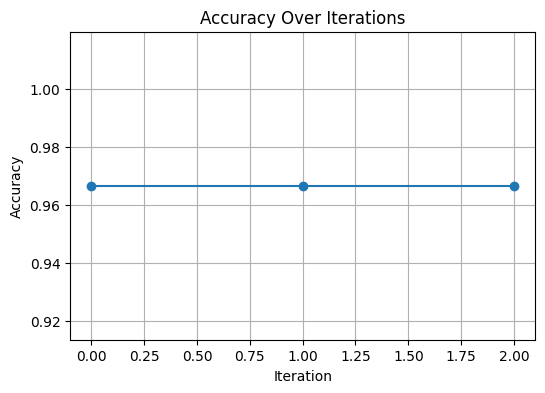

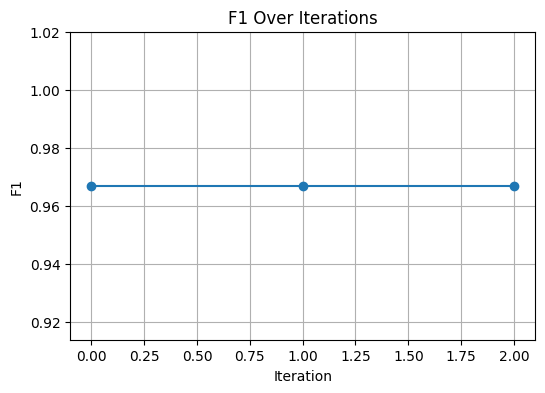

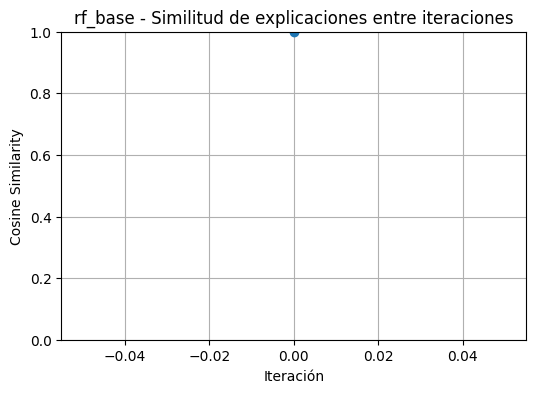

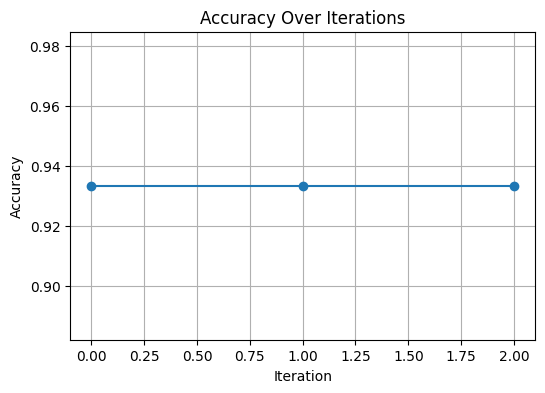

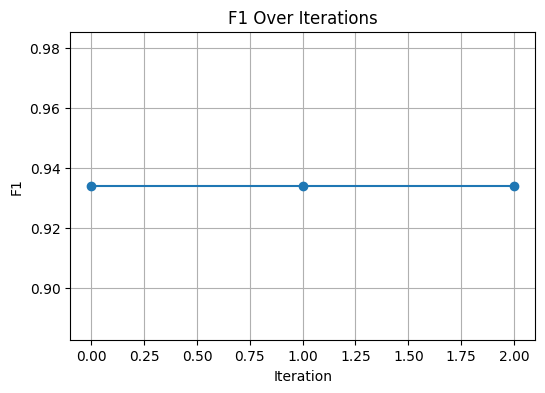

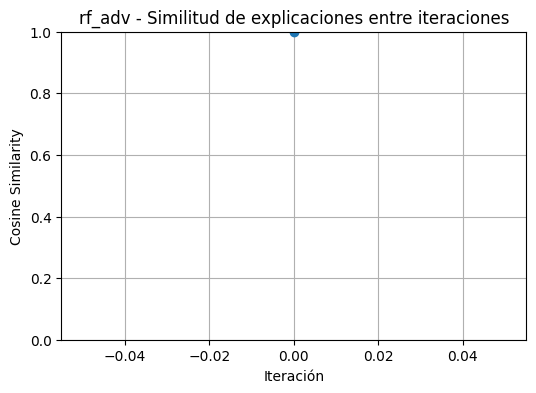

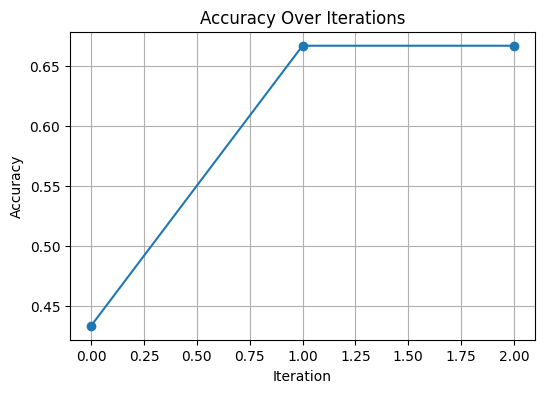

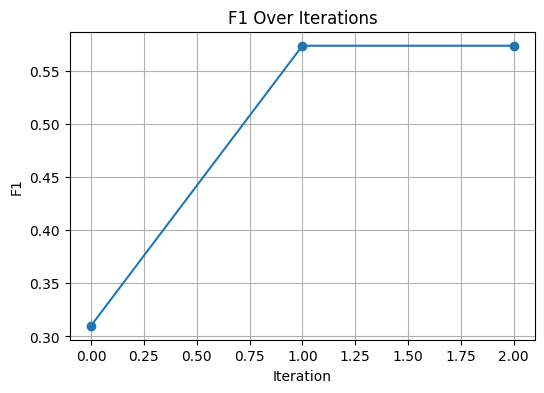

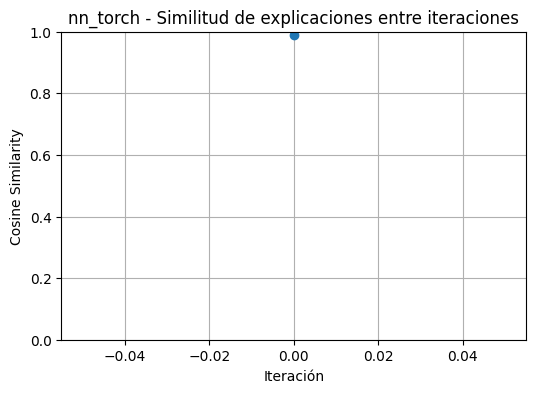


[Visualización] Divergencia global de explicaciones



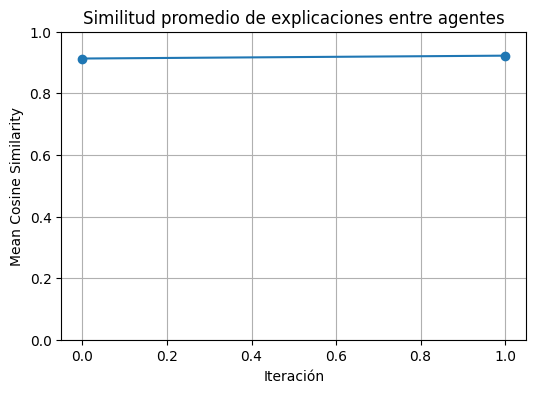


[Visualización] Dashboard global



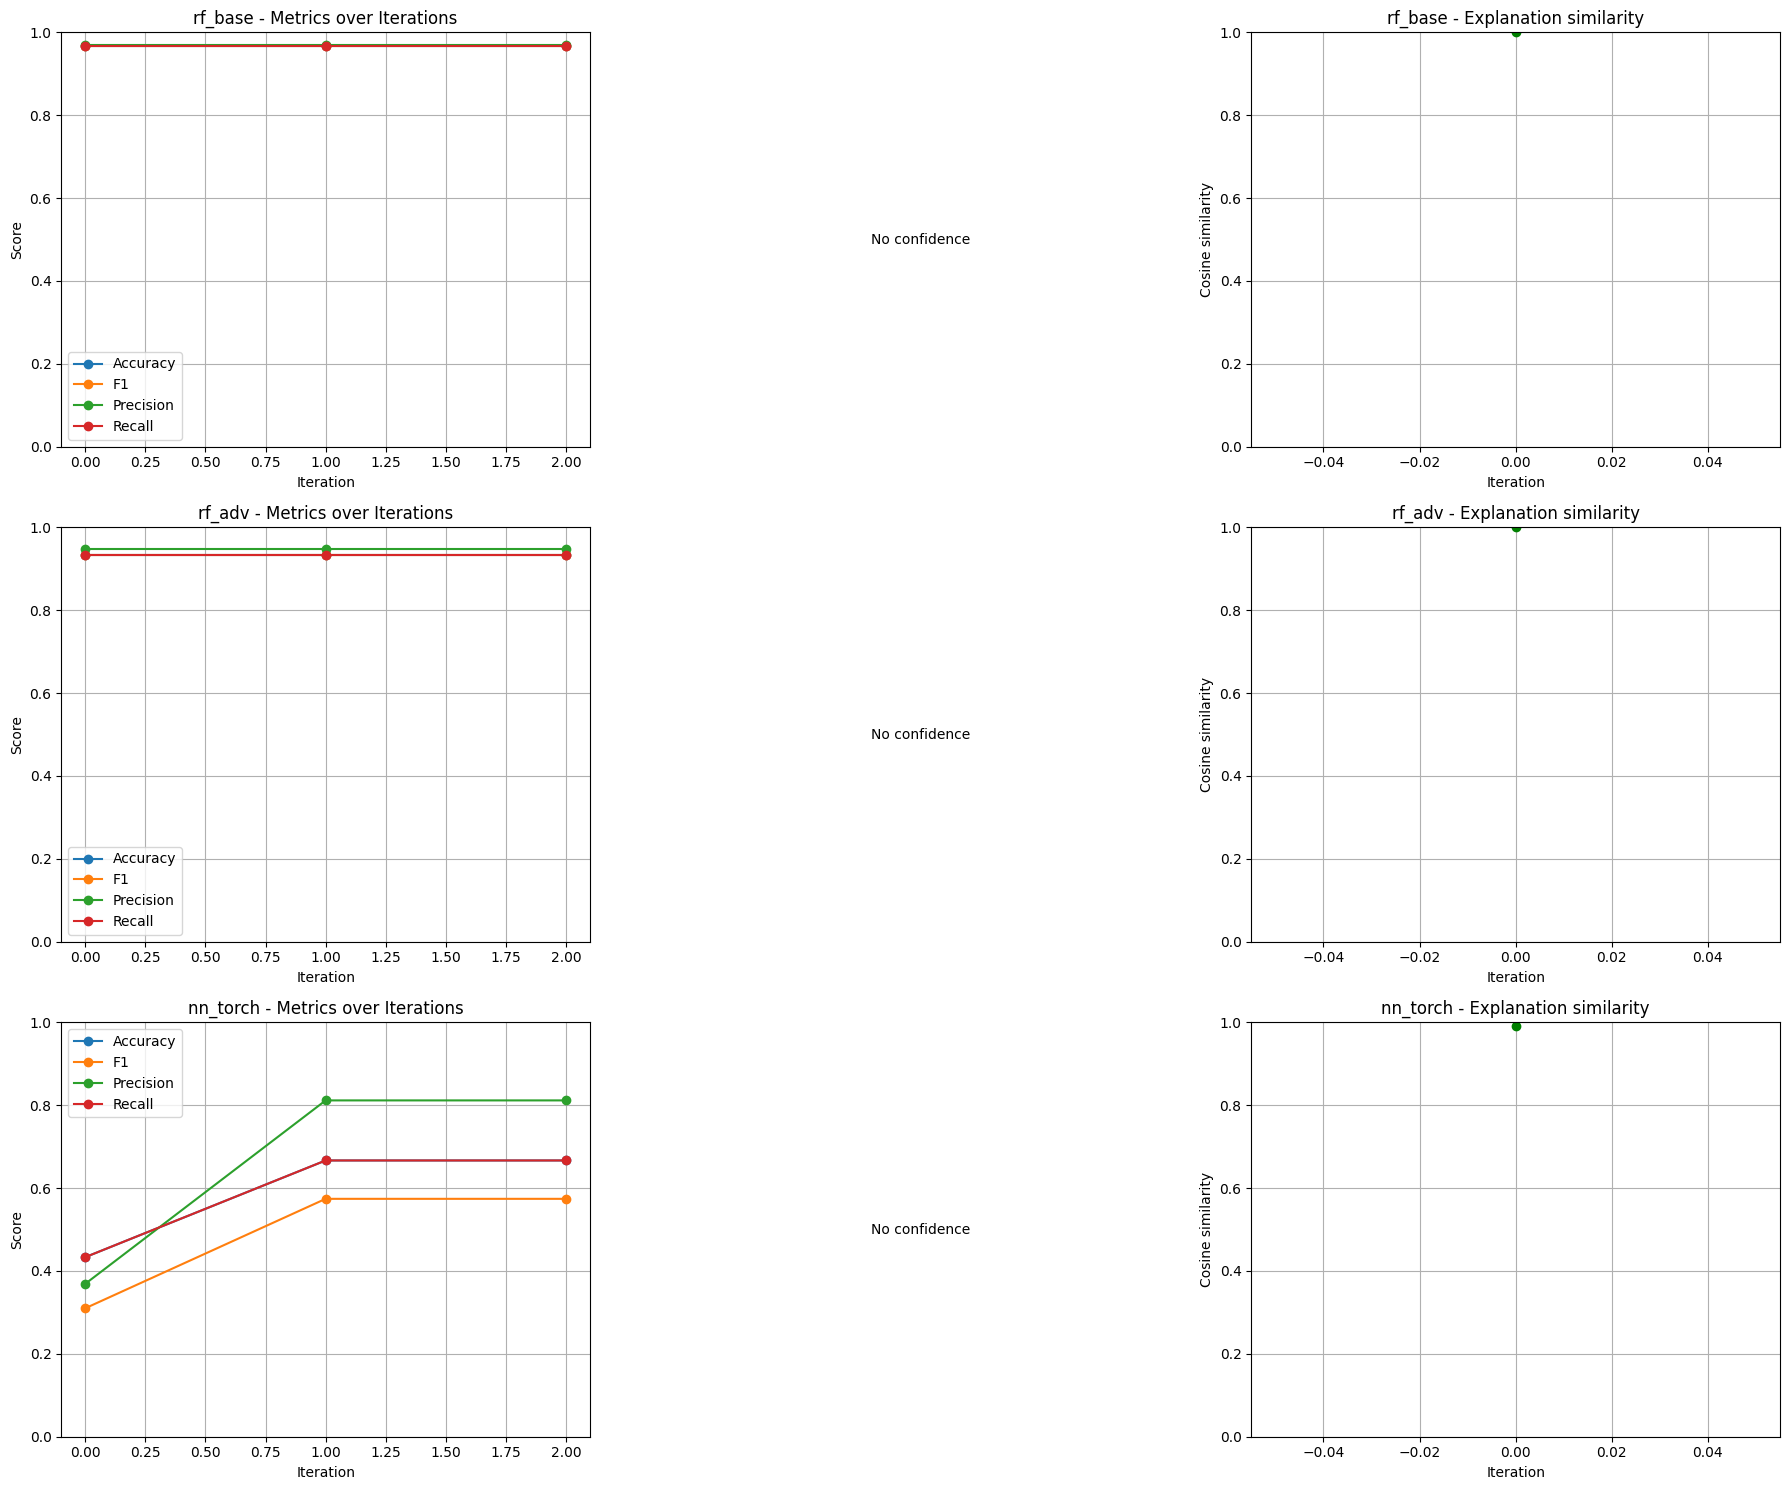

,agent,iteration,accuracy,f1,precision,recall,exp_quality,exp_consensus,exp_stability
2,nn_torch,0,0.433333,0.310069,0.369048,0.433333,0.896442,0.827413,0.999985
5,nn_torch,1,0.666667,0.574074,0.811594,0.666667,0.912825,0.855823,0.998328
1,rf_adv,0,0.933333,0.934007,0.946667,0.933333,0.974864,0.958106,1.000000
4,rf_adv,1,0.933333,0.934007,0.946667,0.933333,0.976920,0.961534,1.000000
0,rf_base,0,0.966667,0.966980,0.970370,0.966667,0.972050,0.953417,1.000000
3,rf_base,1,0.966667,0.966980,0.970370,0.966667,0.969694,0.949490,1.000000


In [5]:
await run_test()
